In [1]:
import pandas as pd

In [ ]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [2]:
dataset=pd.read_csv("Tatacoffee13_21.csv",index_col="Date",parse_dates=True)

In [3]:
dataset.head()

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65


In [4]:
dataset.isnull().sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

In [5]:
import datetime as dt
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

In [6]:
df = dataset.loc[start:end] # picking only the daterange provided in above

In [7]:
stk_data = df

In [8]:
column='Close'

In [9]:
column

'Close'

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()

In [11]:
data1 = Ms.fit_transform(stk_data[[column]])

In [12]:
#Splitting data into Train and Test for TSA
training_size = round(len(data1 ) * 0.80) # identifying the 80% of total records
print(training_size)  
X_train=data1[:training_size]  # assigning the first 80% records into X_train
X_test=data1[training_size:] # assigning the rest of 20% records into X_test
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size] # Same X assignment need to do to Y as well. assigning the first 80% records into y_train
y_test=data1[training_size:] # assigning the rest of 20% records into y_test
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

98
X_train length: (98, 1)
X_test length: (25, 1)
y_train length: (98, 1)
y_test length: (25, 1)


In [14]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
from statsmodels.tsa.arima.model import ARIMA
# Creating loop to check how the model behaves for given parameter and evaluate rmse and mape metrics
trends=['n','t','c','ct']
orders=[(1,0,1),(1,0,2),(2,0,1),(2,0,2)]
for td in trends:
    for o in orders:
        model=ARIMA(X_train, order=o, trend=td)
        model_fit=model.fit()
        y_pred = model_fit.predict(len(X_train),len(data1)-1)  # This is prdicting similar length of series in y_test
        print("The trend and order values are {} and {}.".format(td, o))
        from stockFunctions import rmsemape # calling user defined function which contains metric calculation
        rmsemape(y_test,y_pred)
        print("_______________")

The trend and order values are n and (1, 0, 1).
RMSE-Testset: 0.13336202328996907
maPe-Testset: 0.2530885739976857
_______________
The trend and order values are n and (1, 0, 2).
RMSE-Testset: 0.14314268915866568
maPe-Testset: 0.2879958892144925
_______________
The trend and order values are n and (2, 0, 1).
RMSE-Testset: 0.13346222453497705
maPe-Testset: 0.250962402351724
_______________
The trend and order values are n and (2, 0, 2).
RMSE-Testset: 0.13968087526518536
maPe-Testset: 0.2786170548188963
_______________
The trend and order values are t and (1, 0, 1).
RMSE-Testset: 0.45179990349261245
maPe-Testset: 1.006202811638914
_______________
The trend and order values are t and (1, 0, 2).
RMSE-Testset: 0.4441914558958755
maPe-Testset: 0.9898571985401697
_______________
The trend and order values are t and (2, 0, 1).
RMSE-Testset: 0.44320979171948716
maPe-Testset: 0.985214570744445
_______________
The trend and order values are t and (2, 0, 2).
RMSE-Testset: 0.4480851562423007
maPe-T

Based on above the best value are getting the following parameter The trend and order values are c and (1, 0, 1).
RMSE-Testset: 0.12755624710528732
maPe-Testset: 0.26640274439024575

In [18]:
final_model = ARIMA(X_train, order=(1,0,1), trend='c')
final_model_fit = final_model.fit()
y_pred = final_model_fit.predict(len(X_train),len(data1)-1)

In [20]:
from stockFunctions import rmsemape # calling user defined function which contains metric calculation
rmsemape(y_test,y_pred)

RMSE-Testset: 0.12755624710528732
maPe-Testset: 0.26640274439024575


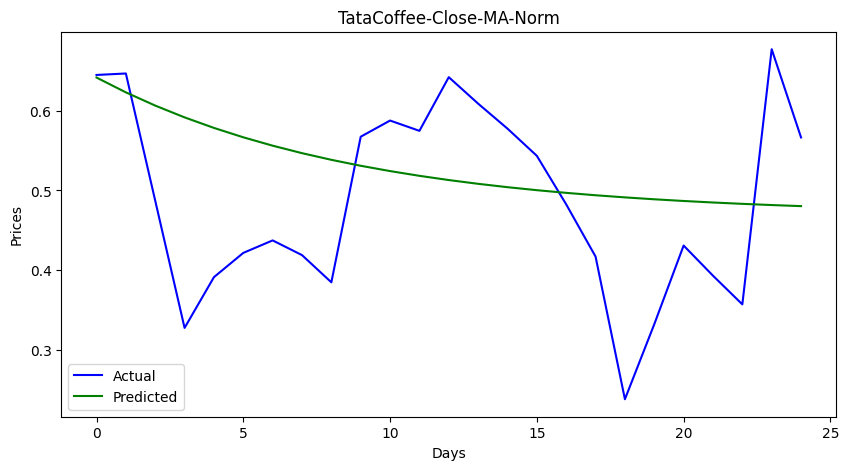

In [21]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [22]:
# Function does the same above for Acutal Test
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])  # this call creates data frame and fill with y_test value
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)  # this call inverse the scaler value from dataframe into original value. Scaler expects DataFrame data
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column]) #this call creates dataframe

In [23]:
# Function does the same above for Predicted Test
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])  #Creating df for predicted value
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable) #inversing the scaler data into Original value 
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column]) # creating data frame.

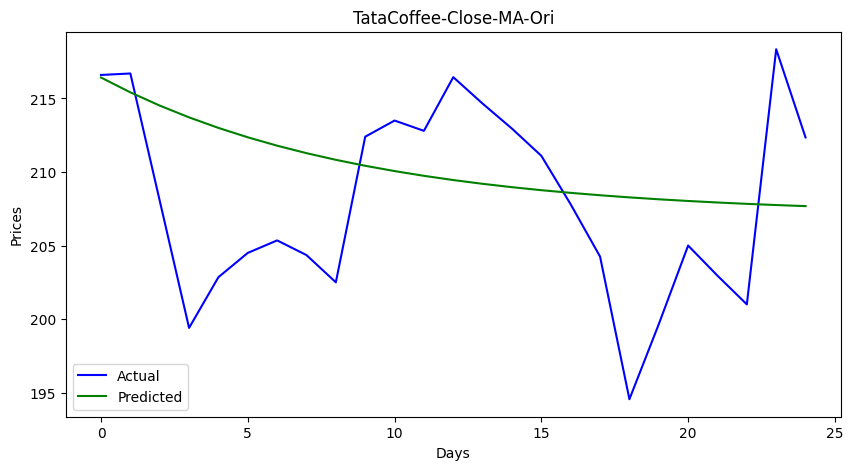

In [24]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")